<a href="https://colab.research.google.com/github/aj11anuj/optimly/blob/main/work/notebooks/w04_baseline_score.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-07 — Baseline Action Score and Top-10 Review

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. My rule and its reason codes

*Write the rule in plain words first. Then the reason codes it can output.*

Flag high impression content at or above the 75th percentile whose CTR is below the average CTR of content in the same search position quartile.
- Score: impressions × (peer CTR − actual CTR)
- Reason code: CTR_BELOW_POSITION_BASELINE
- Action: REVIEW_SNIPPET
- Interpretation: Estimated additional clicks relative to the peer benchmark, not guaranteed gains.

## 2. Build the ranked queue (writes the CSV)

*Code the score, rank everything, write work/outputs/baseline_action_score.csv.*

```
WITH source_data AS (
    SELECT
        report_date,
        client_hash_id,
        content_hash_id,
        gsc_impressions,
        gsc_clicks,
        gsc_sum_position,
        gsc_avg_position
    FROM fact_content_daily_performance
    WHERE report_date >= DATE '2026-03-01'
      AND report_date < DATE '2026-04-01'
      AND gsc_data_available = TRUE
      AND gsc_impressions > 0
      AND gsc_clicks IS NOT NULL
      AND gsc_sum_position IS NOT NULL
),
```

1. Source position audit

```
source_position_audit AS (
    SELECT
        COUNT(*) AS total_rows,
        COUNT(gsc_avg_position) AS rows_with_avg_position,
        COUNT(gsc_sum_position) AS rows_with_sum_position,
        COUNT(*) FILTER (
            WHERE gsc_avg_position IS NOT NULL
              AND gsc_sum_position IS NOT NULL
        ) AS comparable_rows,
        ROUND(AVG(ABS(
            gsc_avg_position -
            gsc_sum_position * 1.0 /
            NULLIF(gsc_impressions, 0)
        )) FILTER (
            WHERE gsc_avg_position IS NOT NULL
              AND gsc_sum_position IS NOT NULL
        ), 8) AS mean_abs_position_difference,
        ROUND(MAX(ABS(
            gsc_avg_position -
            gsc_sum_position * 1.0 /
            NULLIF(gsc_impressions, 0)
        )) FILTER (
            WHERE gsc_avg_position IS NOT NULL
              AND gsc_sum_position IS NOT NULL
        ), 8) AS max_abs_position_difference
    FROM source_data
),
```

2. Aggregate monthly content metrics

```
content_metrics AS (
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS impressions,
        SUM(gsc_clicks) AS clicks,
        SUM(gsc_sum_position) AS sum_position,

        SUM(gsc_sum_position) * 1.0 /
            NULLIF(SUM(gsc_impressions), 0)
            AS avg_position,

        SUM(gsc_avg_position * gsc_impressions) /
            NULLIF(
                SUM(gsc_impressions) FILTER (
                    WHERE gsc_avg_position IS NOT NULL
                ), 0
            ) AS weighted_daily_avg_position,

        SUM(gsc_clicks) * 1.0 /
            NULLIF(SUM(gsc_impressions), 0) AS ctr

    FROM source_data
    GROUP BY client_hash_id, content_hash_id
    HAVING SUM(gsc_impressions) > 0
),
```

3. Validate position aggregation

```
position_validated AS (
    SELECT
        *,
        ROUND(
            avg_position - weighted_daily_avg_position, 8
        ) AS position_aggregation_difference,

        CASE
            WHEN ABS(
                avg_position - weighted_daily_avg_position
            ) < 0.0001
            THEN 'PASS'
            ELSE 'FAIL'
        END AS position_aggregation_check
    FROM content_metrics
),
```

4. Assign position quartiles

```
position_groups AS (
    SELECT
        *,
        NTILE(4) OVER (
            ORDER BY avg_position
        ) AS position_bucket
    FROM position_validated
),
```

5. Calculate peer CTR benchmarks

```
benchmarks AS (
    SELECT
        position_bucket,
        AVG(ctr) AS peer_avg_ctr
    FROM position_groups
    GROUP BY position_bucket
),
```

6. Calculate high impression threshold

```
volume_threshold AS (
    SELECT
        QUANTILE_CONT(impressions, 0.75)
            AS p75_impressions
    FROM content_metrics
),
```

7. Score and validate opportunities

```
scored AS (
    SELECT
        p.client_hash_id,
        p.content_hash_id,
        p.impressions,
        p.clicks,
        ROUND(p.avg_position, 4) AS avg_position,
        ROUND(p.weighted_daily_avg_position, 4)
            AS weighted_daily_avg_position,
        p.sum_position,
        p.position_aggregation_difference,
        p.position_aggregation_check,

        p.ctr AS actual_ctr_fraction,
        b.peer_avg_ctr AS peer_ctr_fraction,
        ROUND(p.ctr * 100, 5) AS actual_ctr_pct,
        ROUND(b.peer_avg_ctr * 100, 5)
            AS peer_avg_ctr_pct,

        ROUND(
            p.impressions * b.peer_avg_ctr, 4
        ) AS expected_clicks,

        ROUND(
            p.impressions * (b.peer_avg_ctr - p.ctr), 4
        ) AS corrected_score,

        ROUND(
            p.impressions * b.peer_avg_ctr - p.clicks, 4
        ) AS independently_calculated_score,

        ROUND(
            (p.impressions * b.peer_avg_ctr - p.clicks)
            - p.impressions * (b.peer_avg_ctr - p.ctr),
            8
        ) AS score_difference,

        CASE
            WHEN ABS(
                (p.impressions * b.peer_avg_ctr - p.clicks)
                - p.impressions * (b.peer_avg_ctr - p.ctr)
            ) < 0.0001
            THEN 'PASS'
            ELSE 'FAIL'
        END AS arithmetic_check,

        CASE
            WHEN ABS(
                p.ctr - p.clicks * 1.0 /
                NULLIF(p.impressions, 0)
            ) < 0.00000001
            THEN 'PASS'
            ELSE 'FAIL'
        END AS ctr_check,

        p.position_bucket,
        ROUND(v.p75_impressions, 2) AS p75_impressions,

        a.total_rows AS source_rows_checked,
        a.rows_with_avg_position,
        a.rows_with_sum_position,
        a.comparable_rows,
        a.mean_abs_position_difference,
        a.max_abs_position_difference,

        CASE
            WHEN a.comparable_rows > 0
             AND a.max_abs_position_difference < 0.0001
            THEN 'PASS'
            ELSE 'FAIL'
        END AS source_position_audit_check,

        'CTR_BELOW_POSITION_BASELINE' AS reason_code,
        'REVIEW_SNIPPET' AS action_label

    FROM position_groups p
    JOIN benchmarks b
      ON p.position_bucket = b.position_bucket
    CROSS JOIN volume_threshold v
    CROSS JOIN source_position_audit a

    WHERE p.impressions >= v.p75_impressions
      AND p.ctr < b.peer_avg_ctr
)
```

8. Return ranked top 10 opportunities

```
SELECT *
FROM scored
ORDER BY corrected_score DESC
LIMIT 10;
```

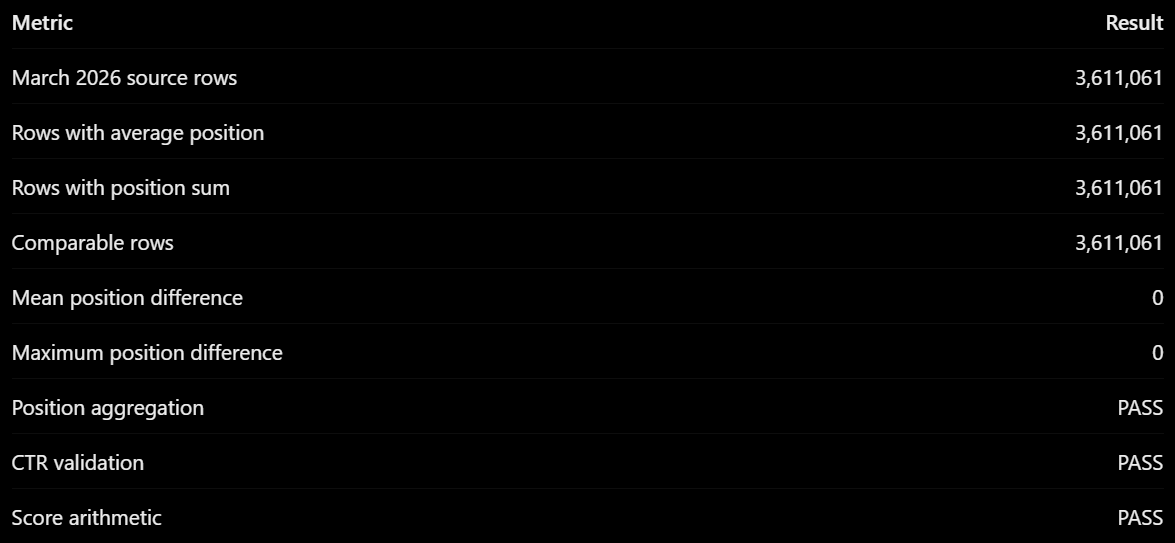

## 3. Top-10 review

*For each of the top 10: action, reason code, confidence note, and what would make it wrong.*

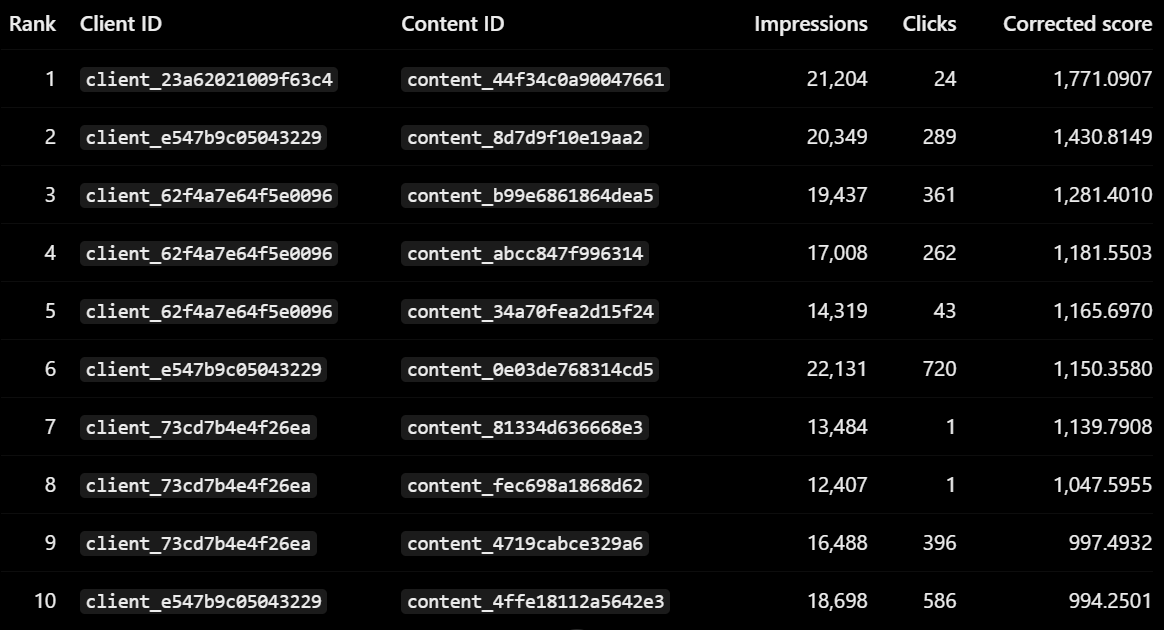

## 4. Weak picks + leakage check

*Which picks look wrong and why? Confirm no product flags or future windows leaked in.*

1.   Very low actual CTRs may reflect differences in search intent, content relevance or query mix, rather than snippet quality.
2.   Each content item contributes to its own position group CTR benchmark.
3.   The SQL explicitly filters March 1 – 31, 2026, excluding later dates.
4.   Not demonstrated in the current query, this needs checking against the notebook's required leakage criteria.
5.   Requires examining the individual content and its context as the scores alone cannot establish that an action is appropriate.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.